In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [7]:
# ---------- 1) Load CSV ----------
csv_path = "seasonal_big_timeseries_5min_2023_2025.csv"  # update path if needed
df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp")
df.set_index("timestamp", inplace=True)
ts = df["value"]

In [8]:
# ---------- 2) Clean & Resample ----------
ts_interp = ts.interpolate(limit_direction="both")          # fill outages for modeling
daily = ts_interp.resample("D").mean()                      # aggregate to daily

C:\Users\sakib\AppData\Local\Temp\ipykernel_4884\1476259675.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  window_end = window_start + pd.Timedelta(days=60)


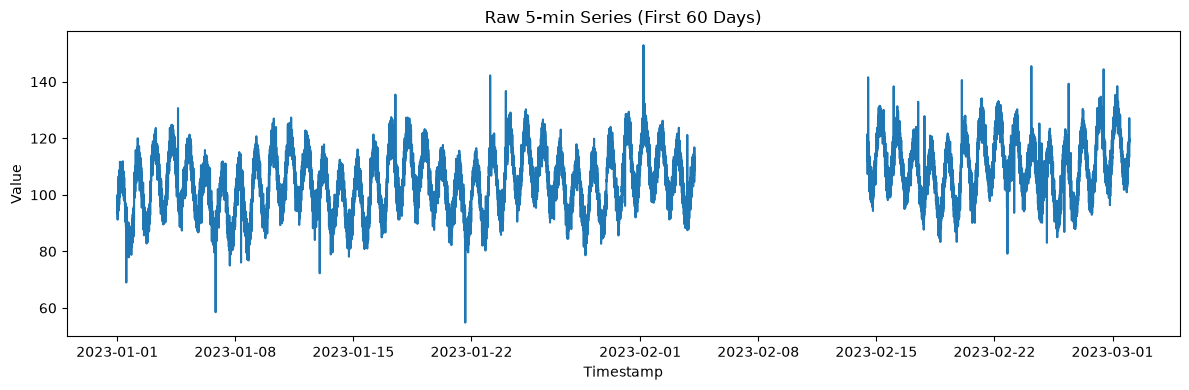

In [9]:
# ---------- 3) Visualizations ----------
# 3.1 Raw 5-min (first 60 days)
window_start = daily.index.min()
window_end = window_start + pd.Timedelta(days=60)
mask = (ts.index >= window_start) & (ts.index <= window_end)
plt.figure(figsize=(12,4)); plt.plot(ts.index[mask], ts.values[mask])
plt.title("Raw 5-min Series (First 60 Days)"); plt.xlabel("Timestamp"); plt.ylabel("Value")
plt.tight_layout(); plt.show()

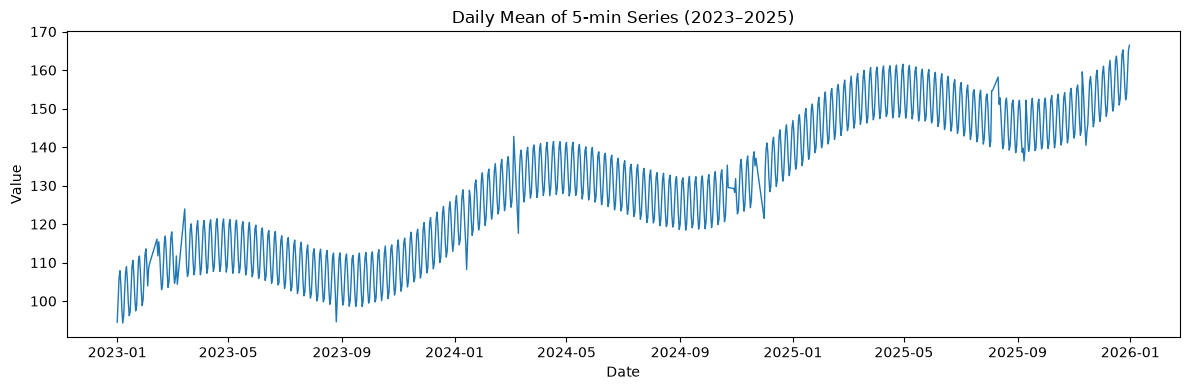

In [10]:
# 3.2 Daily plot (full period)
plt.figure(figsize=(12,4)); plt.plot(daily.index, daily.values, linewidth=1)
plt.title("Daily Mean of 5-min Series (2023–2025)"); plt.xlabel("Date"); plt.ylabel("Value")
plt.tight_layout(); plt.show()